Displaying clean, corrected visual map chart now.


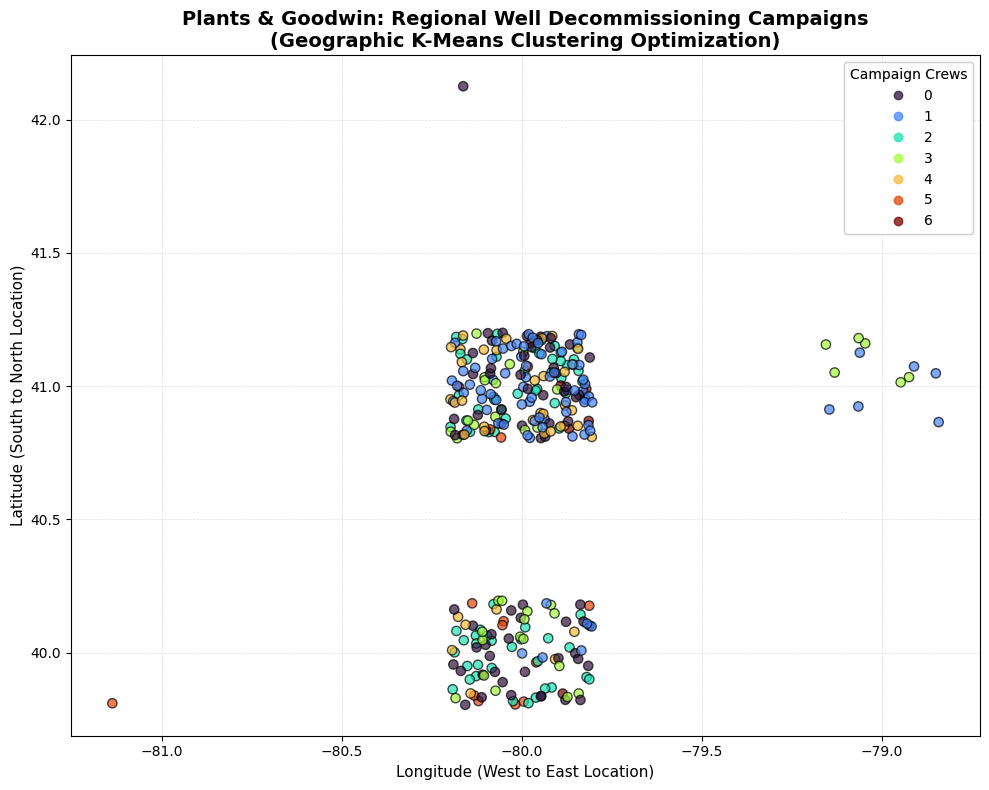

                         WELL_TYPE         WELL_STATUS
campaign_cluster_id                                   
0                    Comb. Oil&Gas  DEP Abandoned List
1                     Undetermined  DEP Abandoned List
2                     Undetermined     DEP Orphan List
3                              Gas  DEP Abandoned List
4                              Oil  DEP Abandoned List
5                              Gas     DEP Orphan List
6                    Comb. Oil&Gas     DEP Orphan List


In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

data_path = "CHOOSE_YOUR_FILE_PATH.csv"

df = pd.read_csv(data_path)

# Remove rows where geographic coordinates are missing
df = df.dropna(subset=['LATITUDE', 'LONGITUDE'])

# Ensure all longitude values are negative (standard for Western Hemisphere)
df['LONGITUDE'] = -df['LONGITUDE'].abs()

# Filter data to a specific bounding box (approx. Pennsylvania/Ohio region)
df = df[(df["LONGITUDE"] >= -82) & (df["LONGITUDE"] <= -78) &
        (df["LATITUDE"] >= 38) & (df["LATITUDE"] <= 43)]

# Set random seed for reproducible data jittering
np.random.seed(42)

# Jitter longitude coordinates to prevent overlapping data points on a map
df['LONGITUDE'] = df['LONGITUDE'] + np.random.uniform(-0.2, 0.2, len(df))

# Jitter latitude coordinates to match the longitude adjustment
df['LATITUDE'] = df['LATITUDE'] + np.random.uniform(-0.2, 0.2, len(df))

# Define categorical features to be used for clustering
features = ['WELL_TYPE', 'WELL_STATUS']

# Convert categorical features into binary/dummy indicator variables
X_encoded = pd.get_dummies(df[features], drop_first=False)

# Initialize KMeans with 7 clusters and explicit initialization settings
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)

# Cluster the encoded categorical data and assign labels to a new column
df['campaign_cluster_id'] = kmeans.fit_predict(X_encoded)

# Initialize a canvas for visual plotting
plt.figure(figsize=(10, 8))

# 4. Plot using the clean, jittered data
scatter = plt.scatter(
    df["LONGITUDE"],
    df["LATITUDE"],
    c=df["campaign_cluster_id"],
    cmap="turbo",
    alpha=0.7,
    edgecolors="k",
    s=45,
)
# 5. Add the legend and clean formatting
legend = plt.legend(
    *scatter.legend_elements(), title="Campaign Crews", loc="upper right"
)
plt.gca().add_artist(legend)

plt.title(
    "Plants & Goodwin: Regional Well Decommissioning Campaigns\n(Geographic K-Means Clustering Optimization)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Longitude (West to East Location)", fontsize=11)
plt.ylabel("Latitude (South to North Location)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

print("Displaying clean, corrected visual map chart now.")
plt.show()
#Create a tier profile grouping campaign cluster id and features together using Lambda in order to dinf the most frequent category for Well_Type and Well_Status starting with 0
tier_profiles = df.groupby('campaign_cluster_id')[features].agg(lambda x: x.mode()[0])
print(tier_profiles)